In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr

In [5]:
df = pd.read_csv('creditcard.csv')

corr_with_target = df.corr()["Class"].sort_values(ascending=False)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


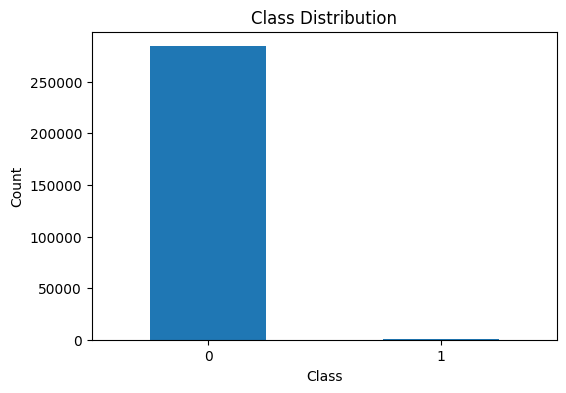

In [6]:
df['Class'].value_counts().plot(kind='bar', figsize=(6, 4),rot=0)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()


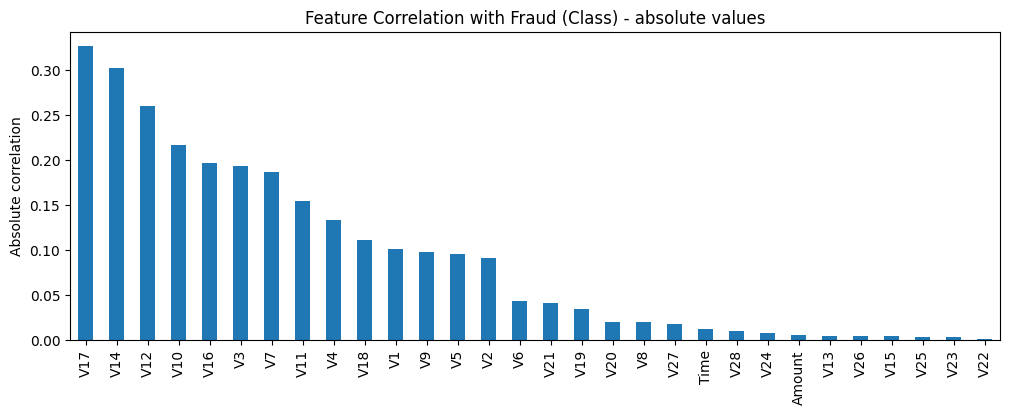

In [7]:
corr_with_target.abs().sort_values(ascending=False).drop("Class").plot(kind="bar", figsize=(12,4))
plt.title("Feature Correlation with Fraud (Class) - absolute values")
plt.ylabel("Absolute correlation")
plt.show()

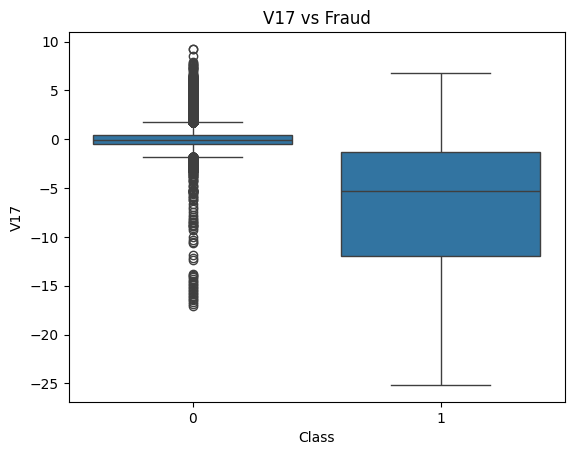

--- Statistische Kennzahlen für V17 ---
       Mittelwert  Median  Std-Abw.     Min    Max      Q1     Q3     IQR  Spannweite
Class                                                                                
0           0.012  -0.065     0.749 -17.098  9.254  -0.483  0.400   0.883      26.352
1          -6.666  -5.303     6.971 -25.163  6.739 -11.945 -1.342  10.603      31.902




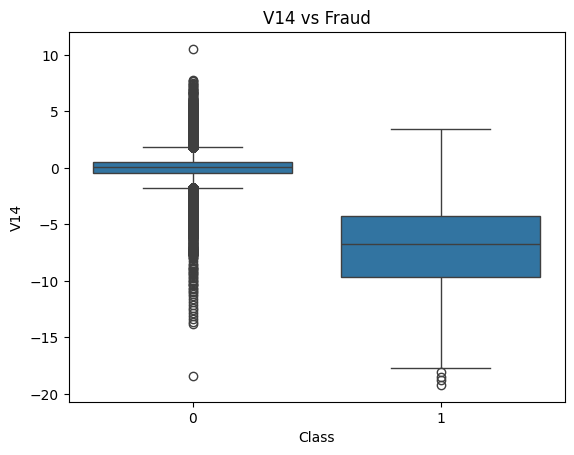

--- Statistische Kennzahlen für V14 ---
       Mittelwert  Median  Std-Abw.     Min     Max     Q1     Q3    IQR  Spannweite
Class                                                                               
0           0.012   0.052     0.897 -18.392  10.527 -0.422  0.494  0.917      28.919
1          -6.972  -6.730     4.279 -19.214   3.442 -9.693 -4.283  5.410      22.657




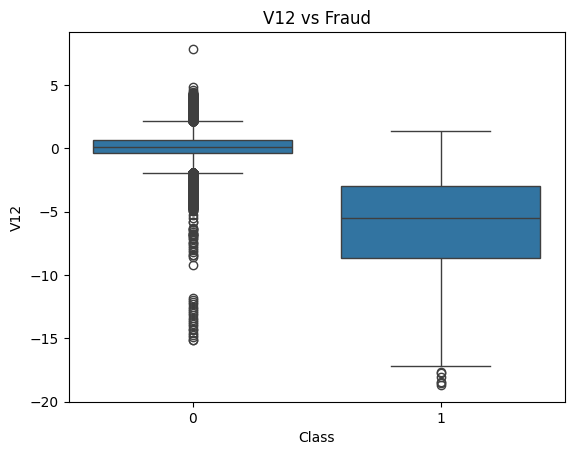

--- Statistische Kennzahlen für V12 ---
       Mittelwert  Median  Std-Abw.     Min    Max     Q1     Q3    IQR  Spannweite
Class                                                                              
0           0.011   0.142     0.946 -15.145  7.848 -0.402  0.619  1.021      22.993
1          -6.259  -5.503     4.654 -18.684  1.376 -8.688 -2.974  5.714      20.060




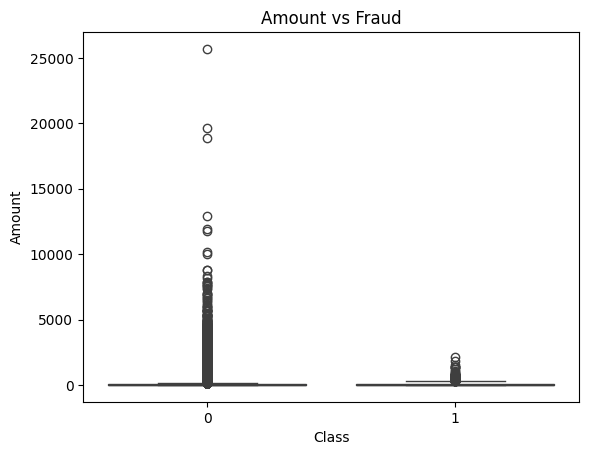

--- Statistische Kennzahlen für Amount ---
       Mittelwert  Median  Std-Abw.  Min       Max    Q1      Q3     IQR  Spannweite
Class                                                                               
0          88.291   22.00   250.105  0.0  25691.16  5.65   77.05   71.40    25691.16
1         122.211    9.25   256.683  0.0   2125.87  1.00  105.89  104.89     2125.87




In [8]:
for col in ["V17", "V14", "V12", "Amount"]:
    sns.boxplot(x="Class", y=col, data=df)
    plt.title(f"{col} vs Fraud")
    plt.show()

    # 2. Die statistischen Kennzahlen nach Klasse getrennt berechnen
    # describe() liefert count, mean, std, min, 25% (Q1), 50% (Median), 75% (Q3), max
    stats = df.groupby("Class")[col].describe()
    
    # 3. Best-Practice Ergänzungen: IQR (Interquartilsabstand) und Spannweite berechnen
    stats['IQR'] = stats['75%'] - stats['25%']
    stats['Spannweite (Range)'] = stats['max'] - stats['min']
    
    # Spalten ordnen und für die Präsentation schöner benennen
    stats_display = stats[['mean', '50%', 'std', 'min', 'max', '25%', '75%', 'IQR', 'Spannweite (Range)']].copy()
    stats_display.columns = ['Mittelwert', 'Median', 'Std-Abw.', 'Min', 'Max', 'Q1', 'Q3', 'IQR', 'Spannweite']
    
    # 4. Tabelle sauber formatiert unter dem Plot ausgeben
    print(f"--- Statistische Kennzahlen für {col} ---")
    # .round(3) rundet die Werte auf 3 Nachkommastellen für bessere Lesbarkeit
    print(stats_display.round(3).to_string())
    print("\n" + "="*80 + "\n")

In [9]:
r_amount, p_amount = pointbiserialr(df["Class"], df["Amount"])
#r_time, p_time = pointbiserialr(df["Class"], df["Time"])

print("Amount correlation:", r_amount, "p-value:", p_amount)
#print("Time correlation:", r_time, "p-value:", p_time)

Amount correlation: 0.005631753006768601 p-value: 0.002651220649191781


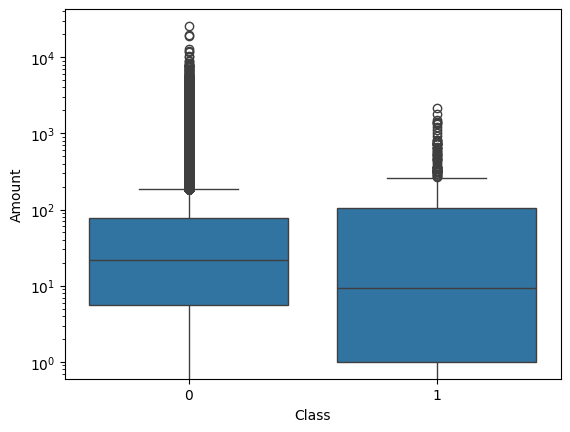

In [10]:
sns.boxplot(x="Class", y="Amount", data=df)
plt.yscale("log")
plt.show()

#sns.boxplot(x="Class", y="Time", data=df)
#plt.show()

In [11]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [12]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


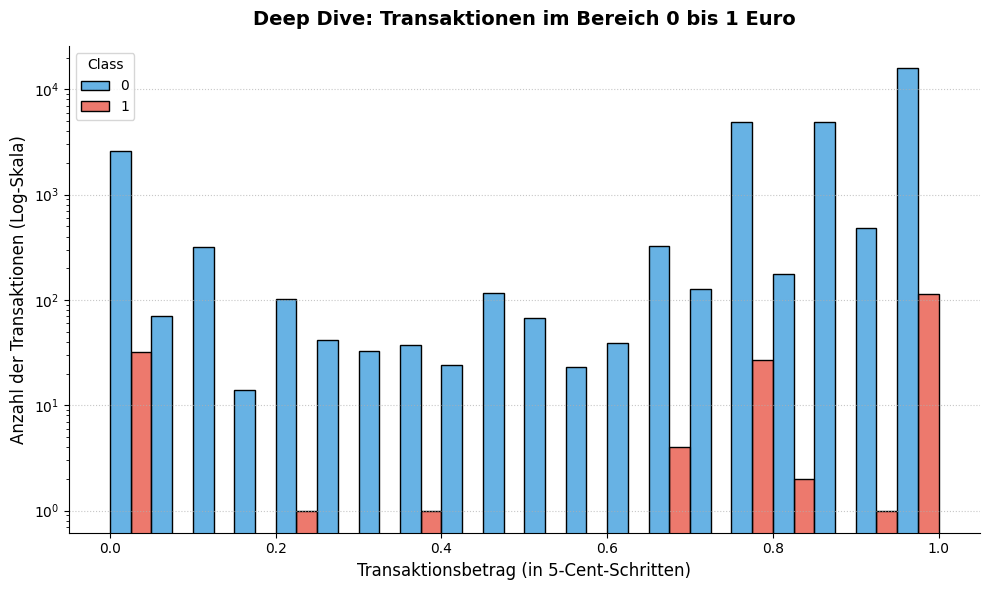

In [14]:
# 1. Daten filtern: Wir nehmen NUR die Transaktionen zwischen 0 und 1 Euro
df_zoomed = df[(df['Amount'] >= 0) & (df['Amount'] <= 1)]

# 2. Das Diagramm aufbauen (Histogramm)
plt.figure(figsize=(10, 6))

# 'multiple="dodge"' setzt die blauen und roten Balken schön nebeneinander
# 'bins=20' teilt den Bereich von 0 bis 1 in 20 kleine Abschnitte (je 5 Cent)
sns.histplot(data=df_zoomed, x="Amount", hue="Class", 
             bins=20, multiple="dodge", 
             palette=["#3498db", "#e74c3c"]) # Blau für Legal, Rot für Betrug

# 3. Beschriftung und Design (Perfekt für die Folie)
plt.title("Deep Dive: Transaktionen im Bereich 0 bis 1 Euro", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Transaktionsbetrag (in 5-Cent-Schritten)", fontsize=12)
plt.yscale('log')
plt.ylabel("Anzahl der Transaktionen (Log-Skala)", fontsize=12)

# X-Achse so einstellen, dass man die Werte von 0.0 bis 1.0 schön lesen kann
plt.xlim(-0.05, 1.05)
plt.grid(axis='y', linestyle=':', alpha=0.7)

# Einen sauberen Rand erzeugen und anzeigen
sns.despine()
plt.tight_layout()
plt.show()